# Seaborn Real-world EDA

End-to-end exploratory data analysis using everything 
The dataset: **Palmer Penguins**. Real measurements of 344 penguins
(species, body dimensions, sex, island) from the Antarctic Palmer
Archipelago. Standard substitute for the iris dataset in modern teaching.

EDA goal: understand the data well enough to build a sensible model
that predicts species from body measurements.



## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
np.random.seed(0)

# In a real project this would be: pd.read_csv("penguins.csv")
df = sns.load_dataset("penguins")
print("Shape:", df.shape)
df.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Step 1: First look — what is in this data

Standard initial checks: shape, dtypes, missing values, summary stats.


In [2]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [3]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

A few missing values. Mostly in gender (11 rows), some in the four
numeric measurements (2 rows each, same rows).


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df.describe(include="object")

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


From the summaries:
- 3 species (Adelie most common at 152), 3 islands, sex roughly balanced.
- Bill length: ~33-60 mm. Bill depth: ~13-22 mm. Flipper: ~172-231 mm.
  Body mass: ~2700-6300 g (a wide range — there's clearly size variation).

The combination of "wide body mass range" and "3 species" suggests the
species differ in size. Worth checking.


## Step 2: Missing data  drop or impute?

13 rows have missing values out of 344. That's small enough to drop.
For a larger fraction, we would impute (fill with median or model-based predictions). Here, dropping is fine.


In [6]:
df_clean = df.dropna().reset_index(drop=True)
print(f"Dropped {len(df) - len(df_clean)} rows. Remaining: {len(df_clean)}")

Dropped 11 rows. Remaining: 333


## Step 3: Categorical variables — class balance

Before anything else, check if classes are balanced. Imbalanced classes
require special handling later.


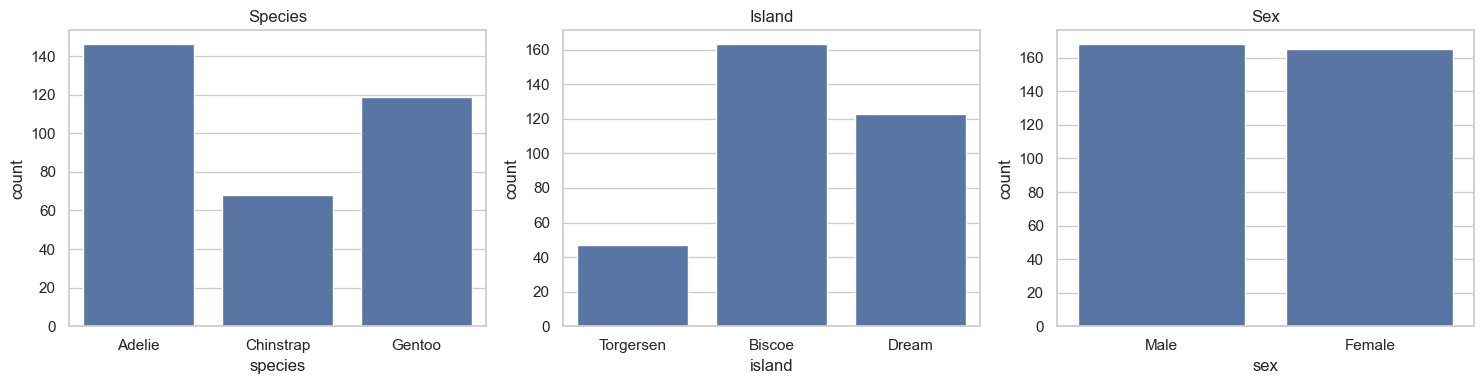

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df_clean, x="species", ax=axes[0])
axes[0].set_title("Species")

sns.countplot(data=df_clean, x="island", ax=axes[1])
axes[1].set_title("Island")

sns.countplot(data=df_clean, x="sex", ax=axes[2])
axes[2].set_title("Sex")

plt.tight_layout()
plt.show()

Observations:
- Species: Adelie dominates (~146), Gentoo and Chinstrap smaller (~119, ~68).
  Moderately imbalanced.
- Island: Biscoe and Dream have the most penguins, Torgersen the fewest.
- Sex: nearly balanced (good).

Worth checking: do all species live on all islands?


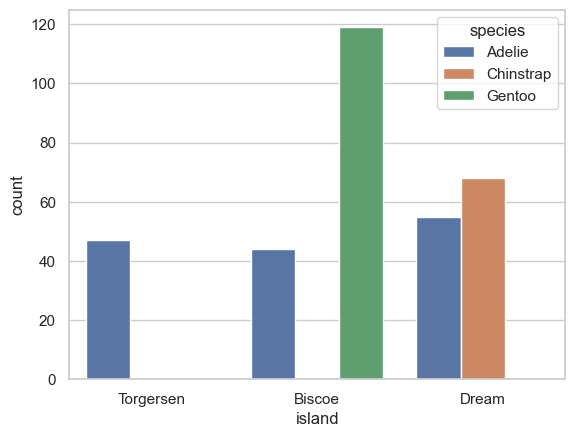

In [8]:
sns.countplot(data=df_clean, x="island", hue="species")
plt.show()

**Important discovery:** species and island are correlated.
- Adelie lives on all three islands.
- Chinstrap lives only on Dream.
- Gentoo lives only on Biscoe.

If we use island as a feature for predicting species, it would leak
strong information. For a fair ML setup we should probably exclude
island or treat it carefully.


## Step 4: Distribution of each numeric feature

How are the four numeric measurements distributed? Are they
approximately normal? Skewed? Multimodal?


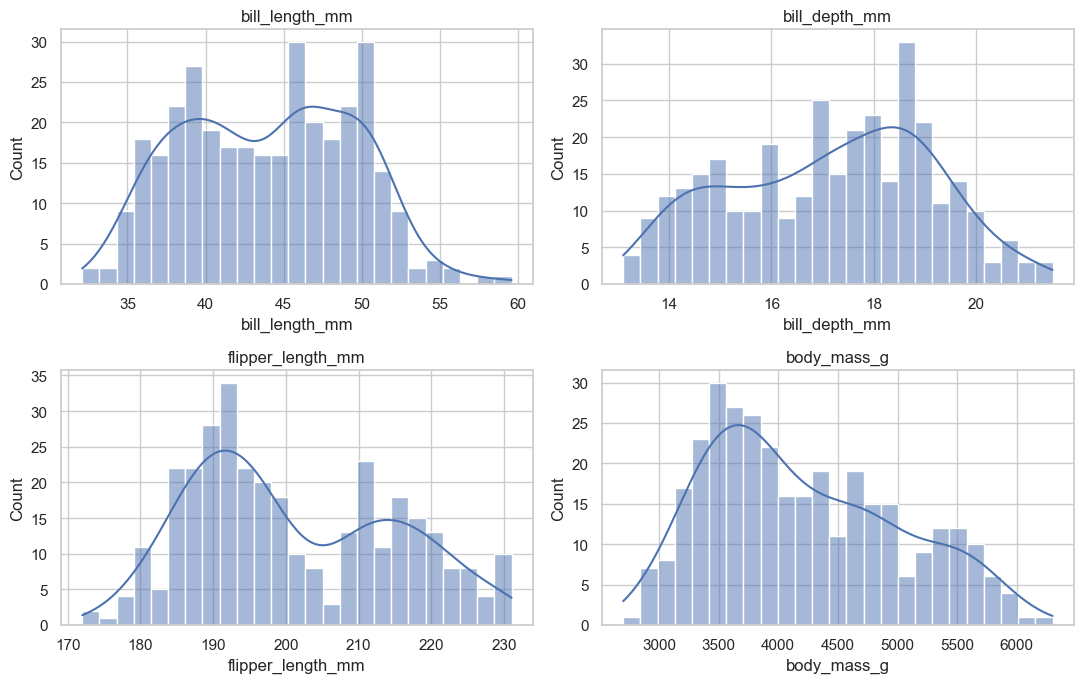

In [9]:
numeric_cols = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df_clean, x=col, kde=True, ax=ax, bins=25)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Observations:
- All four show a bimodal or multimodal shape, especially body mass
  and flipper length.
- The bumps are likely the different species. Let's color by species
  and confirm.


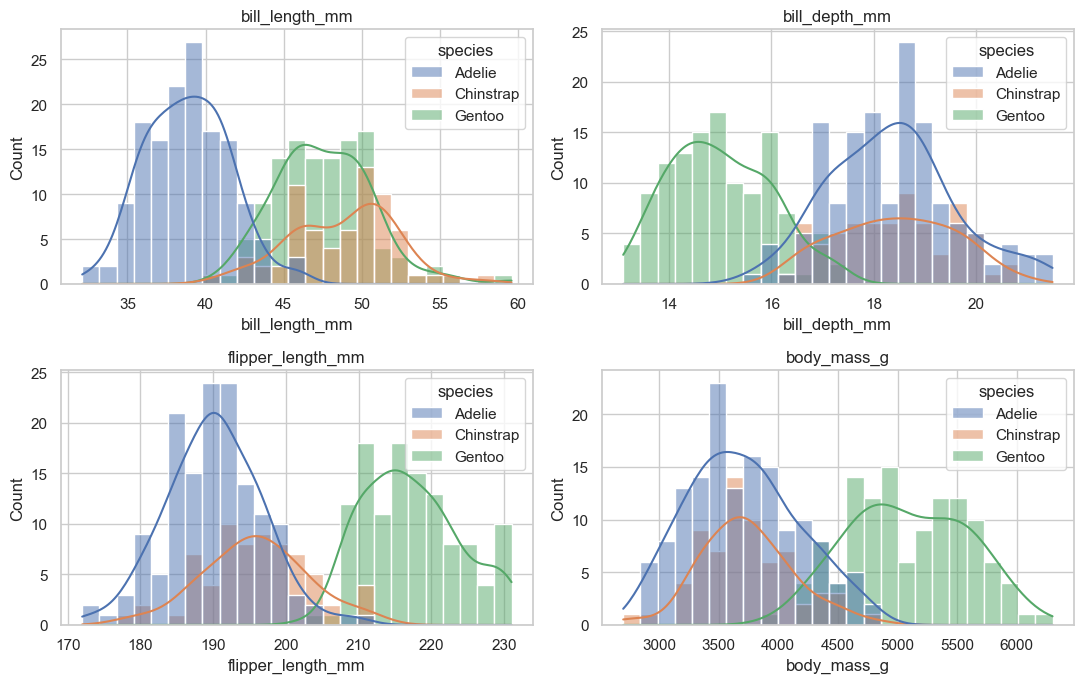

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df_clean, x=col, hue="species", kde=True,
                 ax=ax, bins=25, multiple="layer")
    ax.set_title(col)

plt.tight_layout()
plt.show()

Now the structure is clear:
- **Bill length** separates Adelie (short) from the other two.
- **Bill depth** separates Gentoo (low) from the other two.
- **Flipper length** and **body mass** separate Gentoo (large) from
  Adelie/Chinstrap (smaller).

So bill measurements separate within Adelie/Chinstrap/Gentoo in
different ways. Both bill length AND bill depth should be useful
features.


## Step 5: Pairwise relationships — the pair plot

The single most informative EDA plot for tabular data.


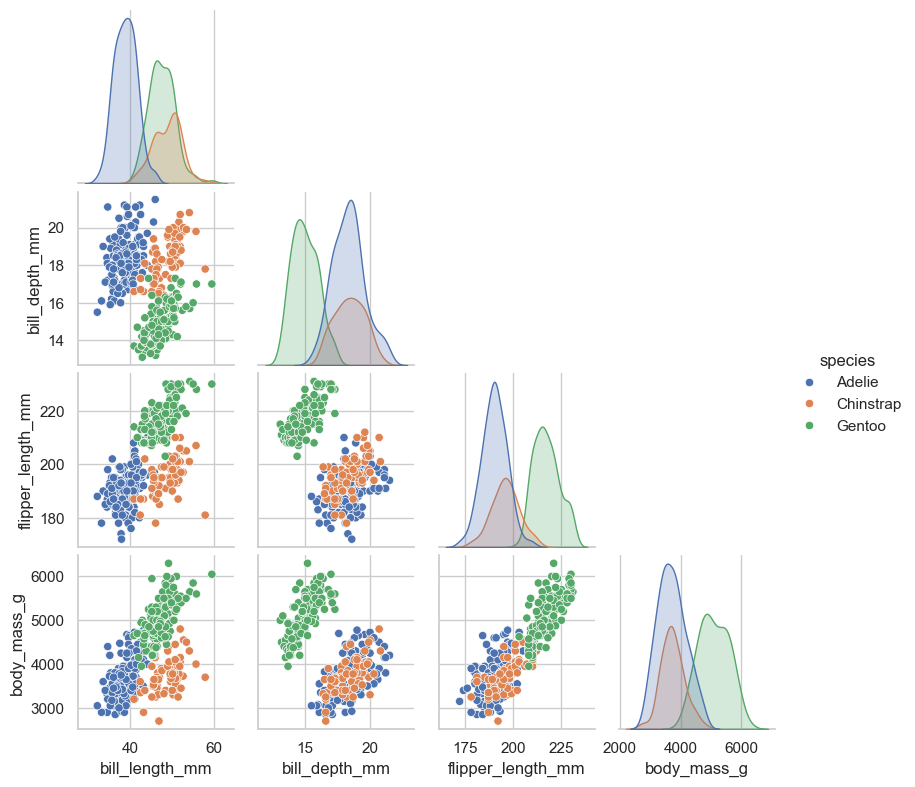

In [11]:
sns.pairplot(
    df_clean,
    hue="species",
    vars=numeric_cols,
    corner=True,
    height=2,
    diag_kind="kde",
)
plt.show()

Reading this:

- **bill_length vs bill_depth** (top-right scatter in the lower
  triangle): clean separation of all three species. This is the most
  informative 2D view.
- **flipper_length vs body_mass**: separates Gentoo (top-right) but
  Adelie and Chinstrap overlap heavily.
- The diagonal KDEs reinforce: bill length is best for separating
  Adelie, bill depth is best for separating Gentoo.

If we had to pick two features for a 2D classifier, **bill length and
bill depth** would be the obvious choice.


## Step 6: Correlations

How correlated are the four numeric features with each other?


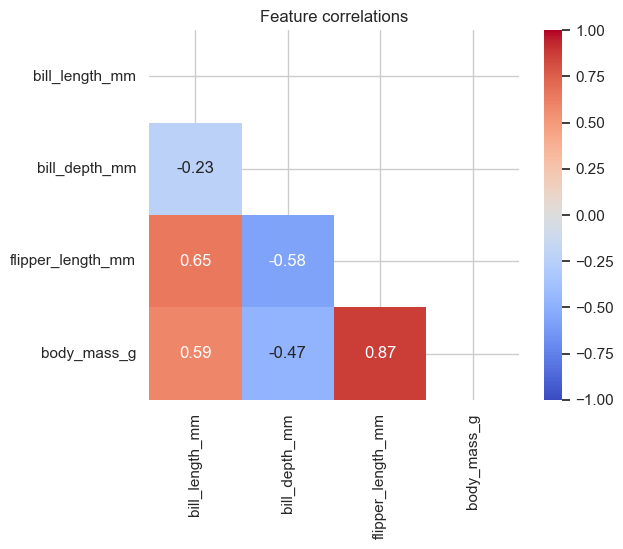

In [12]:
corr = df_clean[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
)
plt.title("Feature correlations")
plt.show()

Observations:
- `flipper_length` and `body_mass` are 0.87 correlated. Bigger penguins
  have longer flippers — expected.
- `bill_depth` is negatively correlated with the other three. This is
  Simpson's paradox at work — within species, bigger penguins have
  bigger bills; but across species, Gentoo penguins are larger overall
  yet have shallower bills.
- `bill_length` correlates weakly with everything else, making it a
  relatively independent piece of information.

For modeling, this matters: if we have two strongly correlated features,
one is mostly redundant. Tree-based models handle this gracefully;
linear models can struggle.


## Step 7: Distributions across species

The pair plot showed bivariate structure. Box/violin plots let us
compare distributions cleanly.


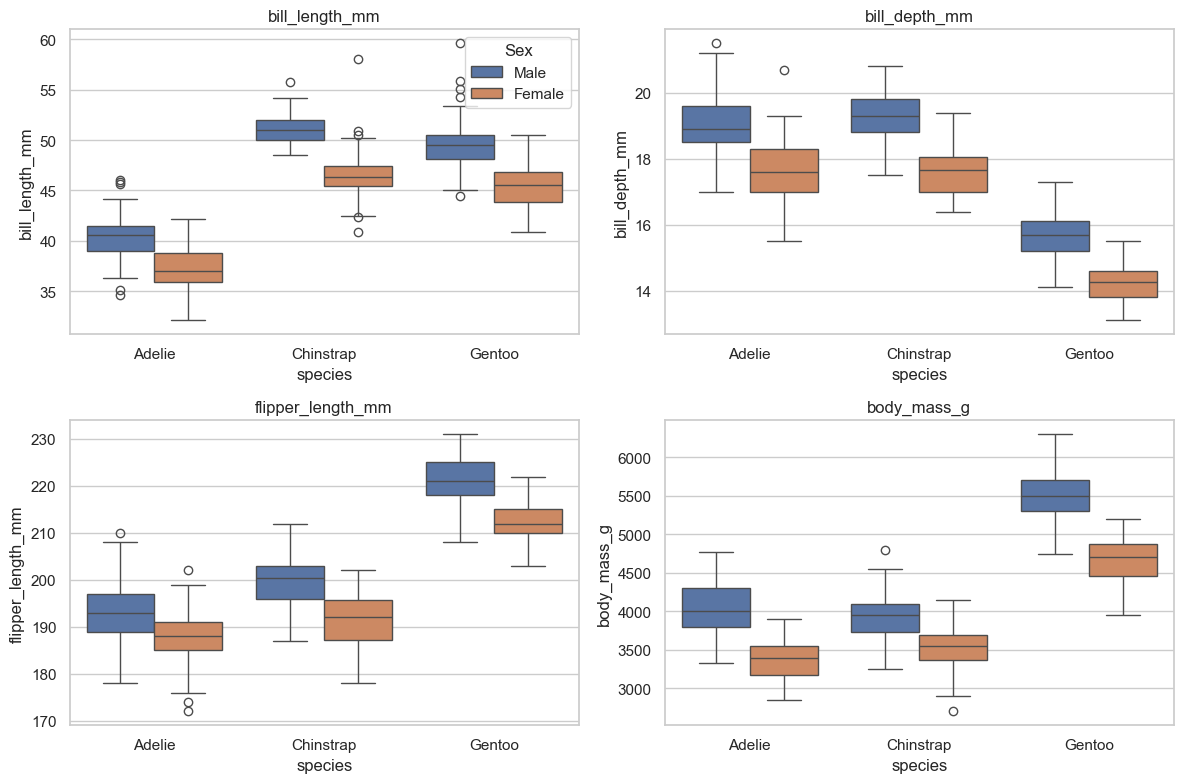

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df_clean, x="species", y=col, hue="sex", ax=ax)
    ax.set_title(col)
    ax.get_legend().remove()

# One shared legend
axes[0, 0].legend(title="Sex", loc="upper right")
plt.tight_layout()
plt.show()

Observations:

- **Sex effect is consistent**: across all species and measurements,
  males are larger than females. This is sexual dimorphism — we should
  consider sex when comparing penguins.
- **Adelie vs Chinstrap on bill length**: Chinstrap has noticeably
  longer bills, with little overlap.
- **Gentoo on body mass**: substantially larger than the other two.


## Step 8: A focused two-feature view

Earlier we noted that bill length + bill depth give the cleanest
species separation. Let's confirm with a joint plot.


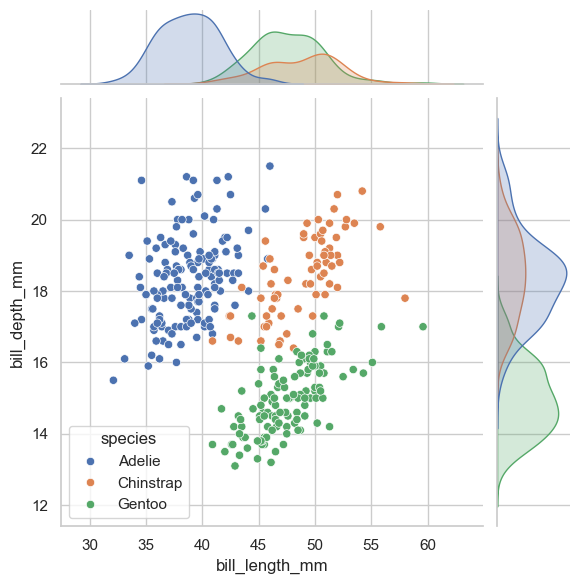

In [14]:
sns.jointplot(
    data=df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    height=6,
)
plt.show()

Three nearly non-overlapping clusters. A simple classifier using
just these two features would already do very well. This is the kind of
plot to lead a report with — it tells the whole story in one frame.


## Step 9: A summary chart for the writeup

Putting it together: one plot that captures the main finding.


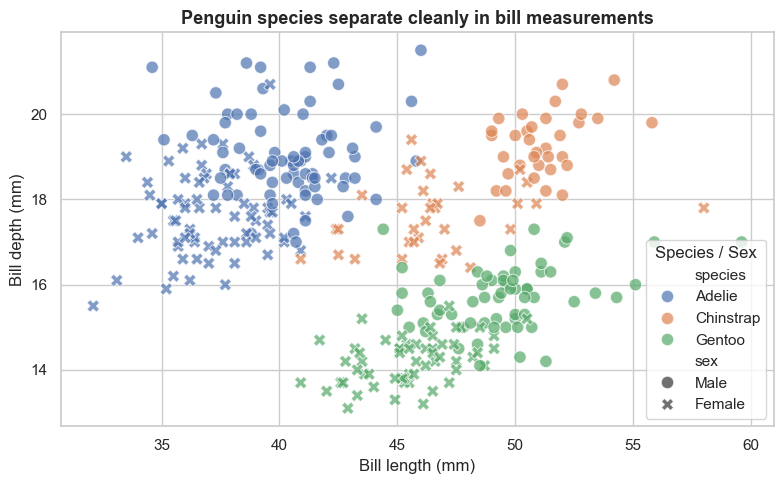

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex",
    s=80,
    alpha=0.7,
    ax=ax,
)

ax.set_xlabel("Bill length (mm)", fontsize=12)
ax.set_ylabel("Bill depth (mm)", fontsize=12)
ax.set_title("Penguin species separate cleanly in bill measurements",
             fontsize=13, fontweight="bold")
ax.legend(title="Species / Sex", loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

## Summary of what we learned

1. **Three species** with moderately imbalanced counts (Adelie > Gentoo
   > Chinstrap).
2. **Species and island are strongly linked** — island would leak
   species information if used as a feature.
3. **All four body measurements vary across species**, with bill
   measurements giving the cleanest separation.
4. **Sexual dimorphism** is consistent: males larger than females
   within each species.
5. **Bill length + bill depth** alone are sufficient for clean species
   separation — a 2D classifier on these two features would work well.
6. **Flipper length and body mass are highly correlated** (0.87), so
   they contribute partly redundant information.
7. **Negative correlation between bill depth and the other measurements**
   reflects Simpson's paradox across species.

For a modeling step we would:
- Use bill length, bill depth, and one of {flipper length, body mass}
  as features.
- Possibly include sex as a categorical feature.
- Exclude island (information leak).
- Try a simple model first (logistic regression, decision tree) since
  the classes separate so cleanly in 2D.
